# 04_data_representation 

In this notebook, we will make graphic representation of our data. 


**Inputs**

The complete dataset in csv format, constructed in the previous notebook. 



**Outputs**

Differents representations. 

## 1. Library import 

In [1]:

# Data Processing
import pandas as pd
import numpy as np

# Graphic representation 
import matplotlib.pyplot as plt
import seaborn as sns

# Others 
from sklearn.decomposition import PCA
import joblib


## 2. Data import 

In [2]:
# Download df_gpt 
df_gpt = pd.read_csv("metrics//data//df_gpt.csv")
# Download complete dataset  
df = pd.read_csv("metrics//data//data_fanfic_jk.csv")

In [3]:
# import tf-idf matrix for global data 
tfidf_matrix = joblib.load("metrics//data//tfidf_vectorizer.pkl")
tfidf_matrix = tfidf_matrix.transform(df["paragraph"])

In [4]:
# import tf-idf matrice 
tfidf_gpt = joblib.load("metrics//data//tfidf_vectorizer.pkl")
tfidf_gpt = tfidf_gpt.transform(df_gpt["paragraph"])

In [5]:
print(type(tfidf_matrix))


<class 'scipy.sparse._csr.csr_matrix'>


## 3. Global configuration 

In [6]:


# Apply a global Seaborn theme to ensure consistent and readable plots
sns.set(style="whitegrid")

# Define custom colors for each class:
# - Gold for FanFic texts
# - Purple for J.K. Rowling texts
color_fanfic = "#D4AF37"
color_rowling = "#8E44AD"

# Create color dictionaries that will be reused across all visualizations
# to maintain a consistent visual identity throughout the notebook
palette = {
    "FanFic": color_fanfic,
    "J.K. Rowling": color_rowling
}

# Equivalent palette using the binary labels stored in the dataset
binary_palette = {
    0: color_fanfic,
    1: color_rowling
}

## 4. Graphics Representation for all data 

### 4.1 Target variable 

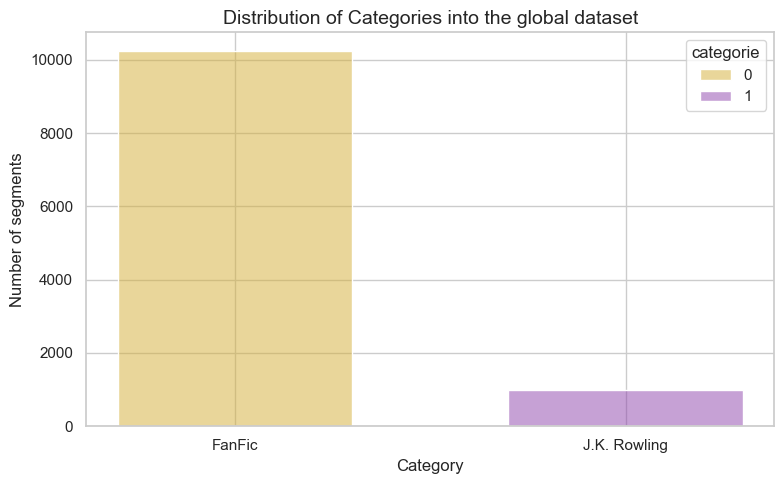

In [7]:
# Create a new figure with a fixed size
plt.figure(figsize=(8,5))

# Display the distribution of the target variable (categorie)
# This allows us to verify whether the dataset is balanced
# between FanFic and J.K. Rowling segments
sns.histplot(
    data=df,
    x="categorie",
    hue="categorie",
    palette=binary_palette,
    discrete=True,
    shrink=0.6
)

# Replace numeric labels with meaningful class names
plt.xticks([0,1], ["FanFic", "J.K. Rowling"])

# Add title and axis labels
plt.title("Distribution of Categories into the global dataset", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of segments")

# Optimize spacing before displaying the figure
plt.tight_layout()
plt.show()

### 4.2 Stylometric variables

In [8]:
# Create a copy of the dataset to avoid modifying the original data
df_plot = df.copy()

# Select the features that require preprocessing before visualization
features = [
    "adv_ratio",
    "avg_word_length",
    "avg_sentence_length"
]

for col in features:

    # Compute the 99th percentile and cap larger values
    # This reduces the influence of extreme outliers
    upper = df_plot[col].quantile(0.99)
    df_plot[col] = np.clip(df_plot[col], None, upper)

    # Apply a logarithmic transformation to reduce skewness
    # log1p(x) = log(1 + x), which safely handles zero values
    df_plot[col] = np.log1p(df_plot[col])

# Create a human-readable version of the target variable
# for use in plots and visual analyses
df_plot["categorie_label"] = df_plot["categorie"].map({
    0: "FanFic",
    1: "J.K. Rowling"
})

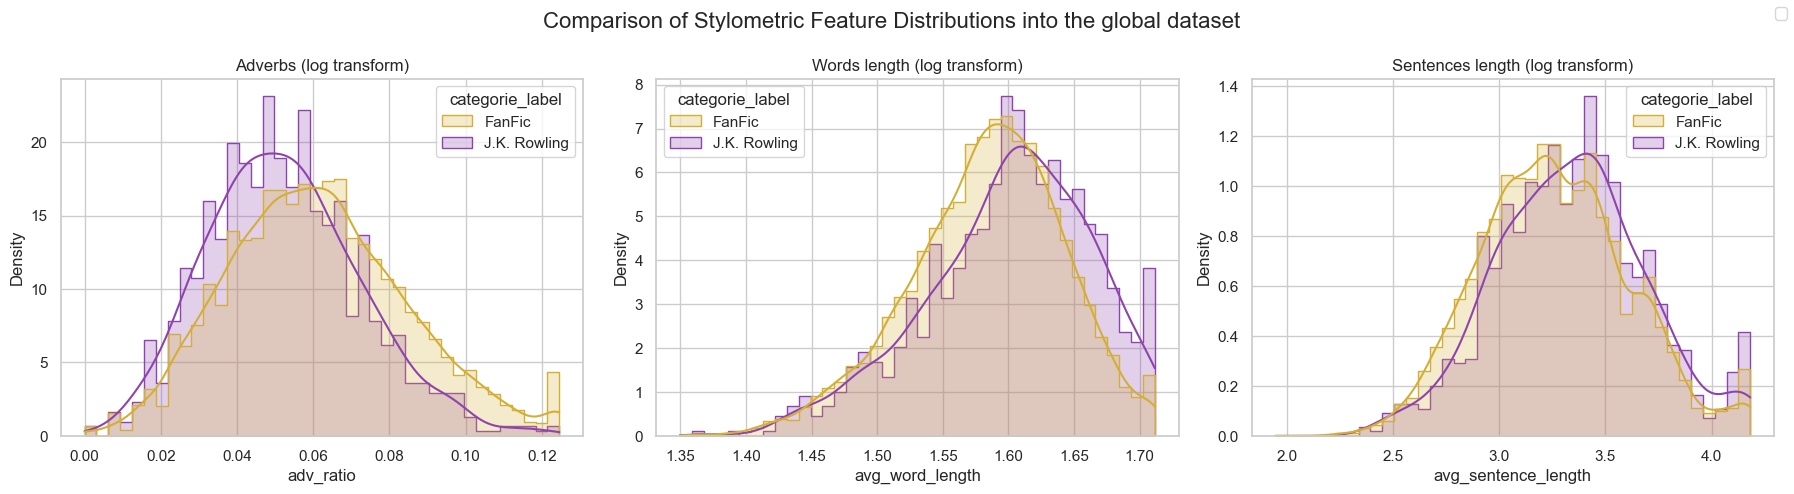

In [9]:
# Create a figure containing three side-by-side subplots
# to compare several stylometric features simultaneously
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# Features selected for comparison between the two classes
features = [
    "adv_ratio",
    "avg_word_length",
    "avg_sentence_length"
]

# Titles displayed above each subplot
titles = [
    "Adverbs (log transform)",
    "Words length (log transform)",
    "Sentences length (log transform)"
]

# Generate one distribution plot for each feature
for i, (feature, title) in enumerate(zip(features, titles)):

    sns.histplot(
        data=df_plot,

        # Feature displayed on the x-axis
        x=feature,

        # Separate distributions according to the text category
        hue="categorie_label",

        # Use the custom color palette defined earlier
        palette=palette,

        # Overlay a kernel density estimation curve
        # to better visualize the shape of the distribution
        kde=True,

        ax=axs[i],

        # Display distributions as outlined histograms
        element="step",

        # Normalize counts into probability densities
        # to allow comparison between classes
        stat="density",

        # Prevent normalization across groups
        common_norm=False,

        bins=40
    )

    # Add subplot title and axis labels
    axs[i].set_title(title)
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel("Density")

# Create a shared legend for the entire figure
handles, _ = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["FanFic", "J.K. Rowling"],
    loc="upper right"
)

# Global title summarizing the comparison
plt.suptitle(
    "Comparison of Stylometric Feature Distributions into the global dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 4.3 TF-IDF

In [10]:

# Reduce the high-dimensional TF-IDF representation
# to only two principal components using PCA
#
# PCA projects the original feature space onto a smaller
# set of orthogonal axes that capture as much variance
# as possible from the data.
pca = PCA(n_components=2)

tfidf_reduced = pca.fit_transform(
    tfidf_matrix.toarray()
)

# Create a DataFrame containing the reduced representation
# for visualization purposes
df_pca = pd.DataFrame()

# First principal component
df_pca["PC1"] = tfidf_reduced[:, 0]

# Second principal component
df_pca["PC2"] = tfidf_reduced[:, 1]

# Store the class labels for coloring the points
df_pca["categorie"] = df["categorie"].values

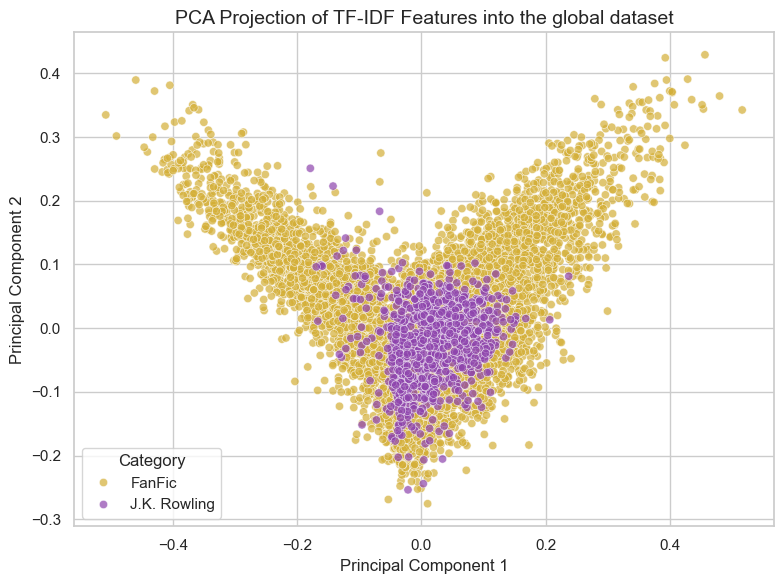

In [11]:
# Create a scatter plot showing the PCA projection
# of all text segments in a two-dimensional space
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,

    # Coordinates defined by the two principal components
    x="PC1",
    y="PC2",

    # Color points according to their category
    hue="categorie",

    palette=binary_palette,

    # Slight transparency to reduce overplotting
    alpha=0.7
)

# Add title and axis labels
plt.title(
    "PCA Projection of TF-IDF Features into the global dataset",
    fontsize=14
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Replace numeric labels by meaningful class names
handles, _ = plt.gca().get_legend_handles_labels()

plt.legend(
    handles,
    ["FanFic", "J.K. Rowling"],
    title="Category"
)

# Adjust spacing and display the figure
plt.tight_layout()
plt.show()

## 5. Graphic representation for restreined data 

### 5.1 Target variable 

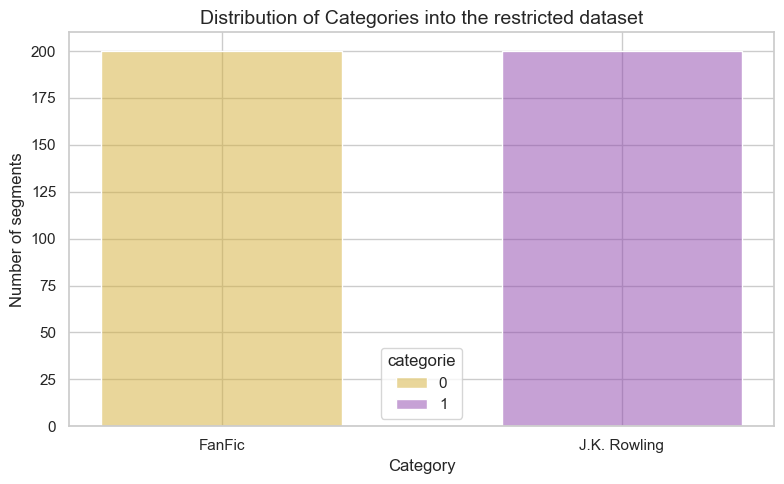

In [12]:
# Create a new figure with a fixed size
plt.figure(figsize=(8,5))

# Display the distribution of the target variable (categorie)
# This allows us to verify whether the dataset is balanced
# between FanFic and J.K. Rowling segments
sns.histplot(
    data=df_gpt,
    x="categorie",
    hue="categorie",
    palette=binary_palette,
    discrete=True,
    shrink=0.6
)

# Replace numeric labels with meaningful class names
plt.xticks([0,1], ["FanFic", "J.K. Rowling"])

# Add title and axis labels
plt.title("Distribution of Categories into the restricted dataset", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Number of segments")

# Optimize spacing before displaying the figure
plt.tight_layout()
plt.show()

### 5.2 Stylometric variables

In [13]:
# Create a copy of the dataset to avoid modifying the original data
df_plot_gpt = df_gpt.copy()

# Select the features that require preprocessing before visualization
features = [
    "adv_ratio",
    "avg_word_length",
    "avg_sentence_length"
]

for col in features:

    # Compute the 99th percentile and cap larger values
    # This reduces the influence of extreme outliers
    upper = df_plot_gpt[col].quantile(0.99)
    df_plot_gpt[col] = np.clip(df_plot_gpt[col], None, upper)

    # Apply a logarithmic transformation to reduce skewness
    # log1p(x) = log(1 + x), which safely handles zero values
    df_plot_gpt[col] = np.log1p(df_plot_gpt[col])

# Create a human-readable version of the target variable
# for use in plots and visual analyses
df_plot_gpt["categorie_label"] = df_plot_gpt["categorie"].map({
    0: "FanFic",
    1: "J.K. Rowling"
})


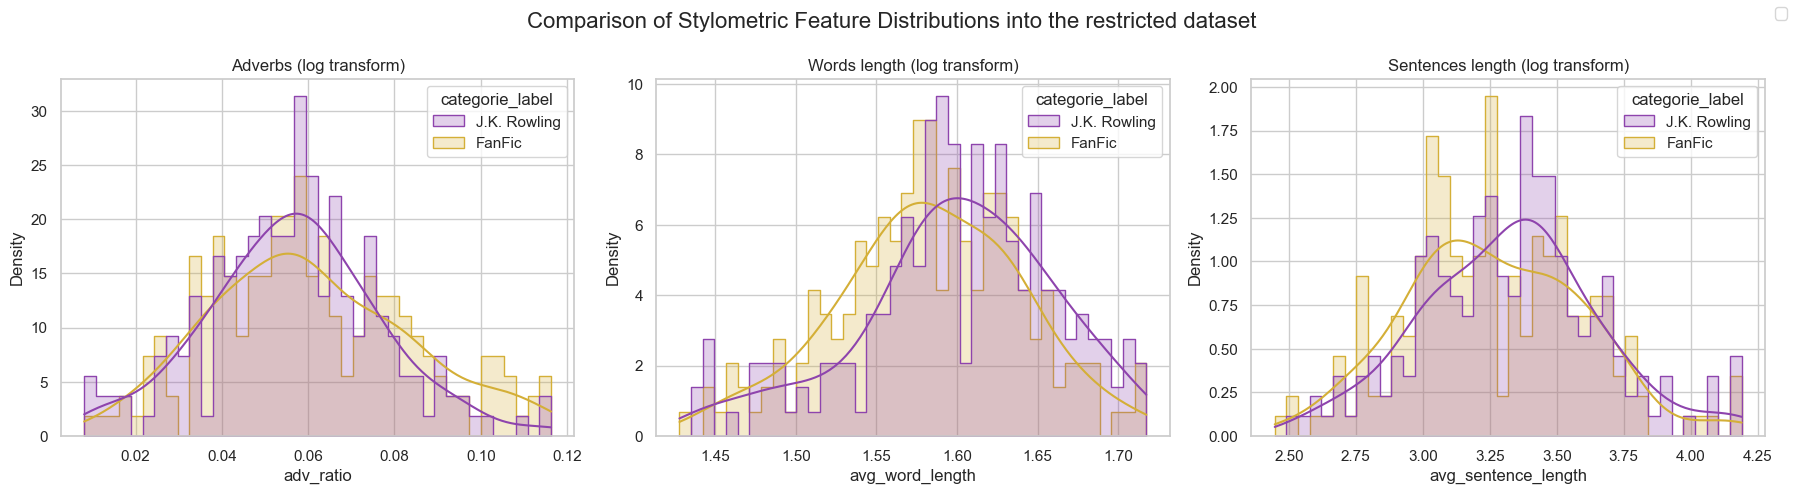

In [14]:
# Create a figure containing three side-by-side subplots
# to compare several stylometric features simultaneously
fig, axs = plt.subplots(1, 3, figsize=(18,5))

# Features selected for comparison between the two classes
features = [
    "adv_ratio",
    "avg_word_length",
    "avg_sentence_length"
]

# Titles displayed above each subplot
titles = [
    "Adverbs (log transform)",
    "Words length (log transform)",
    "Sentences length (log transform)"
]

# Generate one distribution plot for each feature
for i, (feature, title) in enumerate(zip(features, titles)):

    sns.histplot(
        data=df_plot_gpt,

        # Feature displayed on the x-axis
        x=feature,

        # Separate distributions according to the text category
        hue="categorie_label",

        # Use the custom color palette defined earlier
        palette=palette,

        # Overlay a kernel density estimation curve
        # to better visualize the shape of the distribution
        kde=True,

        ax=axs[i],

        # Display distributions as outlined histograms
        element="step",

        # Normalize counts into probability densities
        # to allow comparison between classes
        stat="density",

        # Prevent normalization across groups
        common_norm=False,

        bins=40
    )

    # Add subplot title and axis labels
    axs[i].set_title(title)
    axs[i].set_xlabel(feature)
    axs[i].set_ylabel("Density")

# Create a shared legend for the entire figure
handles, _ = axs[0].get_legend_handles_labels()
fig.legend(
    handles,
    ["FanFic", "J.K. Rowling"],
    loc="upper right"
)

# Global title summarizing the comparison
plt.suptitle(
    "Comparison of Stylometric Feature Distributions into the restricted dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

### 5.3 TF-IDF

In [15]:

# Reduce the high-dimensional TF-IDF representation
# to only two principal components using PCA
#
# PCA projects the original feature space onto a smaller
# set of orthogonal axes that capture as much variance
# as possible from the data.
pca = PCA(n_components=2)

tfidf_reduced_gpt = pca.fit_transform(
    tfidf_gpt.toarray()
)

# Create a DataFrame containing the reduced representation
# for visualization purposes
df_pca_gpt = pd.DataFrame()

# First principal component
df_pca_gpt["PC1"] = tfidf_reduced_gpt[:, 0]

# Second principal component
df_pca_gpt["PC2"] = tfidf_reduced_gpt[:, 1]

# Store the class labels for coloring the points
df_pca_gpt["categorie"] = df_gpt["categorie"].values

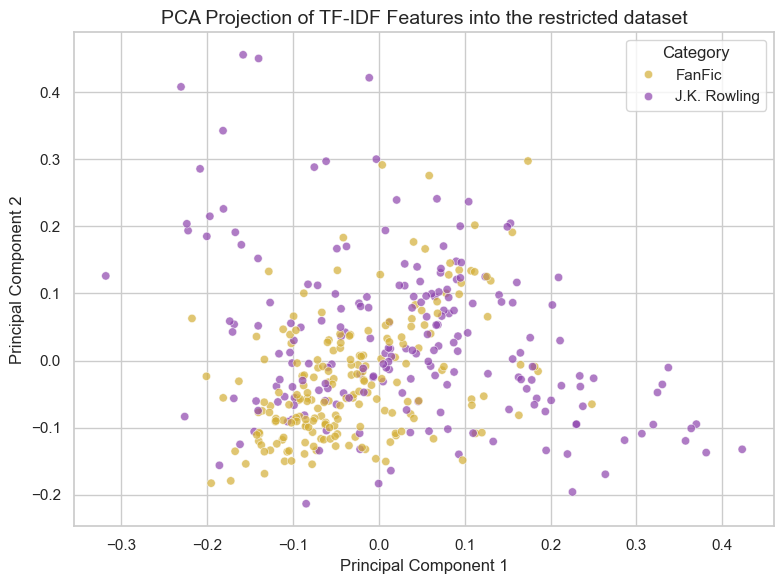

In [16]:
# Create a scatter plot showing the PCA projection
# of all text segments in a two-dimensional space
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca_gpt,

    # Coordinates defined by the two principal components
    x="PC1",
    y="PC2",

    # Color points according to their category
    hue="categorie",

    palette=binary_palette,

    # Slight transparency to reduce overplotting
    alpha=0.7
)

# Add title and axis labels
plt.title(
    "PCA Projection of TF-IDF Features into the restricted dataset",
    fontsize=14
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Replace numeric labels by meaningful class names
handles, _ = plt.gca().get_legend_handles_labels()

plt.legend(
    handles,
    ["FanFic", "J.K. Rowling"],
    title="Category"
)

# Adjust spacing and display the figure
plt.tight_layout()
plt.show()